## Import libereries

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder
from datasist.structdata  import detect_outliers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
%matplotlib inline

### dataset is splited in three files train , test & y test 
so will merge all in one datafram

In [2]:
train_data = pd.read_csv("Dataset for HR Analytics Job Change of Data Scientists\Aug_train.csv", index_col=0) # index_col=0 for use enrollee_id as index
train_data.head(5)

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
enrollee_id,,,,,,,,,,,,,
8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


#### Merge the test data with its target 'y column' in one dataframe

In [3]:
data1 = pd.read_csv("Dataset for HR Analytics Job Change of Data Scientists\Aug_test.csv", index_col=0) # index_col=0 for use enrollee_id as index
data2 = pd.read_csv("Dataset for HR Analytics Job Change of Data Scientists\sample_submission.csv", index_col=0) 
complete_test_data = data1.join(data2, on ='enrollee_id', how= "left")         
complete_test_data.head()

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
enrollee_id,,,,,,,,,,,,,
32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21,0.5
9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98,0.5
31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15,0.5
27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39,0.5
27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72,0.5


In [4]:
data = pd.concat([train_data,complete_test_data],axis=0).reset_index() # Concatenate the two dataframes along the rows (axis=0) and reset the index
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21287 entries, 0 to 21286
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             21287 non-null  int64  
 1   city                    21287 non-null  object 
 2   city_development_index  21287 non-null  float64
 3   gender                  16271 non-null  object 
 4   relevent_experience     21287 non-null  object 
 5   enrolled_university     20870 non-null  object 
 6   education_level         20775 non-null  object 
 7   major_discipline        18162 non-null  object 
 8   experience              21217 non-null  object 
 9   company_size            14727 non-null  object 
 10  company_type            14513 non-null  object 
 11  last_new_job            20824 non-null  object 
 12  training_hours          21287 non-null  int64  
 13  target                  21287 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

### concatenate the train data with complete test data to revert the data to original

In [5]:
data.drop(['enrollee_id','city'],axis=1,inplace=True) # Drop the 'enrollee_id' and 'city' columns from the dataframe
data['looking_for_job_change'] = data['target'].map({0 : 'No' , 1 : 'Yes'}) # Map the target values to the new categories using the mapping dictionary
data

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,looking_for_job_change
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,Yes
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,No
2,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,No
3,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,Yes
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21282,0.920,Male,No relevent experience,no_enrollment,Graduate,Humanities,16,NaN,Public Sector,4,15,0.5,NaN
21283,0.897,Male,Has relevent experience,no_enrollment,Masters,STEM,18,NaN,NaN,2,30,0.5,NaN
21284,0.887,Male,No relevent experience,no_enrollment,Primary School,NaN,3,NaN,Pvt Ltd,never,18,0.5,NaN
21285,0.804,Male,Has relevent experience,Full time course,High School,NaN,7,100-500,Public Sector,1,84,0.5,NaN


In [6]:
copy_data = data.copy() # Create a copy of the concatenated dataframe
data.to_csv("Data_before cleaning.csv", index= False) # Save the concatenated dataframe to a CSV file without the index

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21287 entries, 0 to 21286
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  21287 non-null  float64
 1   gender                  16271 non-null  object 
 2   relevent_experience     21287 non-null  object 
 3   enrolled_university     20870 non-null  object 
 4   education_level         20775 non-null  object 
 5   major_discipline        18162 non-null  object 
 6   experience              21217 non-null  object 
 7   company_size            14727 non-null  object 
 8   company_type            14513 non-null  object 
 9   last_new_job            20824 non-null  object 
 10  training_hours          21287 non-null  int64  
 11  target                  21287 non-null  float64
 12  looking_for_job_change  19158 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 2.1+ MB


In [8]:
data.describe()

,city_development_index,training_hours,target
count,21287.000000,21287.000000,21287.000000
mean,0.828462,65.328510,0.274416
std,0.123537,60.075201,0.417273
min,0.448000,1.000000,0.000000
25%,0.739000,23.000000,0.000000
50%,0.903000,47.000000,0.000000
75%,0.920000,88.000000,0.500000
max,0.949000,336.000000,1.000000


In [9]:
data.describe(include="object")

,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,looking_for_job_change
count,16271,21287,20870,20775,18162,21217,14727,14513,20824,19158
unique,3,2,3,5,6,22,8,6,6,2
top,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1,No
freq,14681,15316,15336,12867,16113,3669,3421,10958,8924,14381


In [10]:
data.isnull().sum()

city_development_index       0
gender                    5016
relevent_experience          0
enrolled_university        417
education_level            512
major_discipline          3125
experience                  70
company_size              6560
company_type              6774
last_new_job               463
training_hours               0
target                       0
looking_for_job_change    2129
dtype: int64

## checking & remove duplicates

In [11]:
data[data.duplicated()].shape[0]

62

In [12]:
data.drop_duplicates(inplace=True) # Drop duplicate rows from the DataFrame
data.reset_index(drop=True, inplace=True) 

In [13]:
data.groupby('gender',dropna=False)[['gender']].count().rename(columns={'gender':'count'}).reset_index().sort_values(by='count', ascending=False)

,gender,count
1,Male,14620
0,Female,1374
2,Other,215
3,NaN,0


In [14]:
pd.DataFrame(data.groupby('gender',dropna=False)[['gender']].count()/data[~data['gender'].isna()]['gender'].count()*100).rename(columns= {'gender':'Percentage'}).reset_index().sort_values(by='Percentage',ascending=False)

,gender,Percentage
1,Male,90.196804
0,Female,8.476772
2,Other,1.326424
3,NaN,0.000000


### Percentage of null data in gender column

In [15]:
print(round(data['gender'].isna().sum()/len(data) *100 ,2) , "% is null data in gender")

23.63 % is null data in gender


#### replace the missing values with the mode of the column which is male = 90 % instead of dropping 23.5% from the data

In [16]:
data['gender'].fillna(data['gender'].mode()[0], inplace=True) # Fill missing values


C:\Users\KING\AppData\Local\Temp\ipykernel_4180\3302207640.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['gender'].fillna(data['gender'].mode()[0], inplace=True) # Fill missing values


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21225 entries, 0 to 21224
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  21225 non-null  float64
 1   gender                  21225 non-null  object 
 2   relevent_experience     21225 non-null  object 
 3   enrolled_university     20808 non-null  object 
 4   education_level         20713 non-null  object 
 5   major_discipline        18104 non-null  object 
 6   experience              21155 non-null  object 
 7   company_size            14689 non-null  object 
 8   company_type            14475 non-null  object 
 9   last_new_job            20762 non-null  object 
 10  training_hours          21225 non-null  int64  
 11  target                  21225 non-null  float64
 12  looking_for_job_change  19098 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 2.1+ MB


In [18]:
data['enrolled_university'].value_counts()

enrolled_university
no_enrollment       15279
Full time course     4187
Part time course     1342
Name: count, dtype: int64

In [19]:
data[data['enrolled_university'].isna()]

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,looking_for_job_change
3,0.789,Male,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,Yes
13,0.624,Male,No relevent experience,NaN,NaN,NaN,2,NaN,NaN,never,24,0.0,No
62,0.827,Male,Has relevent experience,NaN,Masters,STEM,13,<10,NaN,1,15,0.0,No
69,0.698,Male,No relevent experience,NaN,NaN,NaN,2,NaN,Pvt Ltd,never,228,1.0,Yes
171,0.698,Male,Has relevent experience,NaN,NaN,NaN,>20,NaN,NaN,>4,33,0.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20859,0.698,Male,No relevent experience,NaN,NaN,NaN,1,NaN,NaN,NaN,260,0.5,NaN
20936,0.926,Male,Has relevent experience,NaN,Graduate,STEM,5,10/49,Pvt Ltd,2,17,0.5,NaN
21008,0.926,Male,No relevent experience,NaN,Graduate,STEM,12,NaN,NaN,2,104,0.5,NaN
21162,0.743,Male,Has relevent experience,NaN,Masters,STEM,9,1000-4999,NaN,2,66,0.5,NaN


In [20]:
data['education_level'].unique()

array(['Graduate', 'Masters', 'High School', nan, 'Phd', 'Primary School'],
      dtype=object)

In [21]:
data['education_level'].value_counts() 

education_level
Graduate          12812
Masters            4854
High School        2235
Phd                 468
Primary School      344
Name: count, dtype: int64

In [22]:
data['education_level'].dropna(inplace=True)
data.reset_index(drop=True, inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21225 entries, 0 to 21224
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  21225 non-null  float64
 1   gender                  21225 non-null  object 
 2   relevent_experience     21225 non-null  object 
 3   enrolled_university     20808 non-null  object 
 4   education_level         20713 non-null  object 
 5   major_discipline        18104 non-null  object 
 6   experience              21155 non-null  object 
 7   company_size            14689 non-null  object 
 8   company_type            14475 non-null  object 
 9   last_new_job            20762 non-null  object 
 10  training_hours          21225 non-null  int64  
 11  target                  21225 non-null  float64
 12  looking_for_job_change  19098 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 2.1+ MB


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21225 entries, 0 to 21224
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  21225 non-null  float64
 1   gender                  21225 non-null  object 
 2   relevent_experience     21225 non-null  object 
 3   enrolled_university     20808 non-null  object 
 4   education_level         20713 non-null  object 
 5   major_discipline        18104 non-null  object 
 6   experience              21155 non-null  object 
 7   company_size            14689 non-null  object 
 8   company_type            14475 non-null  object 
 9   last_new_job            20762 non-null  object 
 10  training_hours          21225 non-null  int64  
 11  target                  21225 non-null  float64
 12  looking_for_job_change  19098 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 2.1+ MB


In [24]:
data['enrolled_university'].value_counts()

enrolled_university
no_enrollment       15279
Full time course     4187
Part time course     1342
Name: count, dtype: int64

### replace the missing data in 'enrolled_university' with the mod which is no_enrollment

In [25]:
data['enrolled_university'].fillna(data['enrolled_university'].mode()[0], inplace=True) # Fill missing values with the mode of the column

C:\Users\KING\AppData\Local\Temp\ipykernel_4180\1508408690.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['enrolled_university'].fillna(data['enrolled_university'].mode()[0], inplace=True) # Fill missing values with the mode of the column


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21225 entries, 0 to 21224
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  21225 non-null  float64
 1   gender                  21225 non-null  object 
 2   relevent_experience     21225 non-null  object 
 3   enrolled_university     21225 non-null  object 
 4   education_level         20713 non-null  object 
 5   major_discipline        18104 non-null  object 
 6   experience              21155 non-null  object 
 7   company_size            14689 non-null  object 
 8   company_type            14475 non-null  object 
 9   last_new_job            20762 non-null  object 
 10  training_hours          21225 non-null  int64  
 11  target                  21225 non-null  float64
 12  looking_for_job_change  19098 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 2.1+ MB


In [27]:
data.groupby(by=['education_level','major_discipline'],dropna=False)['major_discipline'].value_counts()

education_level  major_discipline
Graduate         Arts                  223
                 Business Degree       261
                 Humanities            472
                 No Major              214
                 Other                 306
                 STEM                11313
                 NaN                    23
High School      NaN                  2235
Masters          Arts                   43
                 Business Degree        98
                 Humanities            248
                 No Major               31
                 Other                 106
                 STEM                 4321
                 NaN                     7
Phd              Arts                    4
                 Business Degree         5
                 Humanities             29
                 Other                   9
                 STEM                  421
Primary School   NaN                   344
NaN              NaN                   512
Name: count, dtype: 

### Drop missing values in major_discipline which will handle also education_level

In [28]:
data.dropna(subset = ['major_discipline'] , inplace=True) # Drop rows with missing values in the major_discipline column
data.reset_index(drop=True, inplace=True) # Reset the index of the DataFrame after dropping rows
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18104 entries, 0 to 18103
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  18104 non-null  float64
 1   gender                  18104 non-null  object 
 2   relevent_experience     18104 non-null  object 
 3   enrolled_university     18104 non-null  object 
 4   education_level         18104 non-null  object 
 5   major_discipline        18104 non-null  object 
 6   experience              18054 non-null  object 
 7   company_size            13458 non-null  object 
 8   company_type            13164 non-null  object 
 9   last_new_job            17769 non-null  object 
 10  training_hours          18104 non-null  int64  
 11  target                  18104 non-null  float64
 12  looking_for_job_change  16289 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.8+ MB


In [29]:
data['experience'].unique()

array(['>20', '15', '5', '<1', '11', '13', '7', '17', '16', '1', '2', '4',
       '10', '14', '18', '19', '12', '6', '9', '3', '8', '20', nan],
      dtype=object)

In [30]:
data.dropna(subset = ['experience'] , inplace=True) # Drop rows with missing values in the experience column
data.reset_index(drop=True, inplace=True) # Reset the index of the DataFrame after dropping rows

In [31]:
data['experience'].value_counts().sort_index(ascending=True)

experience
1       415
10      977
11      677
12      498
13      429
14      601
15      695
16      529
17      356
18      284
19      302
2       856
20      155
3      1111
4      1200
5      1287
6      1124
7       985
8       766
9       973
<1      423
>20    3411
Name: count, dtype: int64

### mapping experience in five groups instead of 21

In [32]:
experience_mapping = {
    '0': 'less_than_3',
    '<1': 'less_than_3',
    '1': 'less_than_3',
    '2': 'less_than_3',
    '3': '3_to_5',
    '4': '3_to_5',
    '5': '3_to_5',
    '6': '6_to_9',
    '7': '6_to_9',
    '8': '6_to_9',
    '9': '6_to_9',
    '10': '10_to_15',
    '11': '10_to_15',
    '12': '10_to_15',
    '13': '10_to_15',
    '14': '10_to_15',
    '15': '10_to_15',
    '16': 'More_than_15',
    '17': 'More_than_15',
    '18': 'More_than_15',
    '19': 'More_than_15',
    '20': 'More_than_15',
    '>20': 'More_than_15',
}

In [33]:
data['experience'] = data['experience'].map(experience_mapping) # Map the experience values to the new categories using the mapping dictionary
data['experience'].value_counts()

experience
More_than_15    5037
10_to_15        3877
6_to_9          3848
3_to_5          3598
less_than_3     1694
Name: count, dtype: int64

In [34]:
data

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,looking_for_job_change
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,More_than_15,NaN,NaN,1,36,1.0,Yes
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,10_to_15,50-99,Pvt Ltd,>4,47,0.0,No
2,0.624,Male,No relevent experience,Full time course,Graduate,STEM,3_to_5,NaN,NaN,never,83,0.0,No
3,0.789,Male,No relevent experience,no_enrollment,Graduate,Business Degree,less_than_3,NaN,Pvt Ltd,never,52,1.0,Yes
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,More_than_15,50-99,Funded Startup,4,8,0.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18049,0.878,Male,No relevent experience,no_enrollment,Masters,STEM,More_than_15,<10,Pvt Ltd,>4,58,0.5,NaN
18050,0.698,Male,No relevent experience,no_enrollment,Graduate,STEM,More_than_15,NaN,NaN,never,133,0.5,NaN
18051,0.920,Male,No relevent experience,no_enrollment,Graduate,Humanities,More_than_15,NaN,Public Sector,4,15,0.5,NaN
18052,0.897,Male,Has relevent experience,no_enrollment,Masters,STEM,More_than_15,NaN,NaN,2,30,0.5,NaN


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18054 entries, 0 to 18053
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  18054 non-null  float64
 1   gender                  18054 non-null  object 
 2   relevent_experience     18054 non-null  object 
 3   enrolled_university     18054 non-null  object 
 4   education_level         18054 non-null  object 
 5   major_discipline        18054 non-null  object 
 6   experience              18054 non-null  object 
 7   company_size            13420 non-null  object 
 8   company_type            13137 non-null  object 
 9   last_new_job            17737 non-null  object 
 10  training_hours          18054 non-null  int64  
 11  target                  18054 non-null  float64
 12  looking_for_job_change  16241 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.8+ MB


In [36]:
data['company_size'].value_counts(dropna=False)

company_size
NaN          4634
50-99        3110
100-500      2647
10000+       2097
10/49        1464
1000-4999    1353
<10          1270
500-999       896
5000-9999     583
Name: count, dtype: int64

In [37]:
data['company_size'].fillna(data['company_size'].mode()[0], inplace=True) # Fill missing values with the mode of the column

C:\Users\KING\AppData\Local\Temp\ipykernel_4180\3633949722.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['company_size'].fillna(data['company_size'].mode()[0], inplace=True) # Fill missing values with the mode of the column


In [38]:
data['company_type'].value_counts(dropna=False)

company_type
Pvt Ltd                9897
NaN                    4917
Funded Startup         1014
Public Sector           985
Early Stage Startup     589
NGO                     535
Other                   117
Name: count, dtype: int64

In [39]:
data['company_type'].fillna(data['company_type'].mode()[0], inplace=True) # Fill missing values with the mode of the column

C:\Users\KING\AppData\Local\Temp\ipykernel_4180\2347615762.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['company_type'].fillna(data['company_type'].mode()[0], inplace=True) # Fill missing values with the mode of the column


In [40]:
data['last_new_job'].value_counts(dropna=False)

last_new_job
1        7825
>4       3354
2        2918
never    1508
4        1068
3        1064
NaN       317
Name: count, dtype: int64

In [41]:
data.dropna(subset=['last_new_job'], inplace=True) # Drop rows with missing values in the last_new_job column
data.reset_index(drop=True, inplace=True) # Reset the index of the DataFrame after dropping rows
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17737 entries, 0 to 17736
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  17737 non-null  float64
 1   gender                  17737 non-null  object 
 2   relevent_experience     17737 non-null  object 
 3   enrolled_university     17737 non-null  object 
 4   education_level         17737 non-null  object 
 5   major_discipline        17737 non-null  object 
 6   experience              17737 non-null  object 
 7   company_size            17737 non-null  object 
 8   company_type            17737 non-null  object 
 9   last_new_job            17737 non-null  object 
 10  training_hours          17737 non-null  int64  
 11  target                  17737 non-null  float64
 12  looking_for_job_change  15951 non-null  object 
dtypes: float64(2), int64(1), object(10)
memory usage: 1.8+ MB


In [42]:
data['last_new_job'] = data['last_new_job'].map({'never' : 0 ,'1' : 1 ,'2' : 2 ,'3' : 3 , '4' : 4 , '>4' : 5}) # Replace 'never' with 0 in the last_new_job column
data['last_new_job'].value_counts()

last_new_job
1    7825
5    3354
2    2918
0    1508
4    1068
3    1064
Name: count, dtype: int64

In [43]:
data['last_new_job'] = data['last_new_job'].astype('int') # Convert the last_new_job column to integer type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17737 entries, 0 to 17736
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  17737 non-null  float64
 1   gender                  17737 non-null  object 
 2   relevent_experience     17737 non-null  object 
 3   enrolled_university     17737 non-null  object 
 4   education_level         17737 non-null  object 
 5   major_discipline        17737 non-null  object 
 6   experience              17737 non-null  object 
 7   company_size            17737 non-null  object 
 8   company_type            17737 non-null  object 
 9   last_new_job            17737 non-null  int64  
 10  training_hours          17737 non-null  int64  
 11  target                  17737 non-null  float64
 12  looking_for_job_change  15951 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 1.8+ MB


In [44]:
data['last_new_job'].value_counts(dropna = False).sort_index()

last_new_job
0    1508
1    7825
2    2918
3    1064
4    1068
5    3354
Name: count, dtype: int64

In [45]:
data['target'].unique()

array([1. , 0. , 0.5])

In [46]:
data['target'].value_counts(dropna=False)

target
0.0    11877
1.0     4074
0.5     1786
Name: count, dtype: int64

In [47]:
data.drop(data[data['target'] == 0.5].index,inplace=True) # Drop the target column from the DataFrame where target is equal to 0.5
data['target'].value_counts(dropna=False)

target
0.0    11877
1.0     4074
Name: count, dtype: int64

In [48]:
#data['looking_for_job_change'] = data['target'].map({0 : 'No' , 1 : 'Yes'}) # Map the target values to the new categories using the mapping dictionary

In [49]:
data.head()

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,looking_for_job_change
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,More_than_15,50-99,Pvt Ltd,1,36,1.0,Yes
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,10_to_15,50-99,Pvt Ltd,5,47,0.0,No
2,0.624,Male,No relevent experience,Full time course,Graduate,STEM,3_to_5,50-99,Pvt Ltd,0,83,0.0,No
3,0.789,Male,No relevent experience,no_enrollment,Graduate,Business Degree,less_than_3,50-99,Pvt Ltd,0,52,1.0,Yes
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,More_than_15,50-99,Funded Startup,4,8,0.0,No


## Visualization

In [50]:
plt.figure(figsize=(10, 8))
px.histogram(data, x='last_new_job', color='looking_for_job_change', facet_col = 'experience',
             title='Distribution of Last New Job by Target', 
             color_discrete_sequence=['red','blue'], 
             barmode='group', 
             labels={'last_new_job': 'Last New Job', 'target': 'Target'})

<Figure size 1000x800 with 0 Axes>

In [51]:
px.pie(data, 'gender',color_discrete_sequence=['blue'] , facet_col= 'looking_for_job_change' ,  title='Gender Distribution' )

In [52]:
px.pie(data, 'relevent_experience',color_discrete_sequence=['Orange'] , facet_col= 'looking_for_job_change' ,hole=.5,  title='Relevent Experience Distribution' )


In [53]:
px.pie(data, 'education_level',color_discrete_sequence=['Green'] , facet_col= 'looking_for_job_change'  ,  title='education_level Distribution',hole=.5)


In [54]:
px.bar(data,x = 'company_type' , y = 'training_hours',facet_col = 'looking_for_job_change',barmode= 'group',color_discrete_sequence=['blue'])

In [55]:
px.bar(data,x = 'company_type' , color = 'looking_for_job_change',barmode='group',facet_col= 'education_level',color_discrete_sequence=['darkblue', 'blue'], title='Company Type vs looking for job change by Education Level')

In [56]:
px.histogram(data,x='experience',color='looking_for_job_change' , barmode='group',color_discrete_sequence=['blue','lightblue'],title='Experience vs looking for job change ')

In [57]:
px.histogram(data,x='city_development_index',color='looking_for_job_change' , barmode='group',color_discrete_sequence=['darkblue','blue'],range_x=(.5,.97),title='City Development Index vs looking for job change ')

In [58]:
px.box(data,x='city_development_index',y='looking_for_job_change',color_discrete_sequence=['blue','lightblue'],title='City Development Index vs Training Hours by Target')

In [59]:
px.box(data,x='training_hours',y='looking_for_job_change',color_discrete_sequence=['blue','lightblue'],title='City Development Index vs Training Hours by Target')

<Axes: >

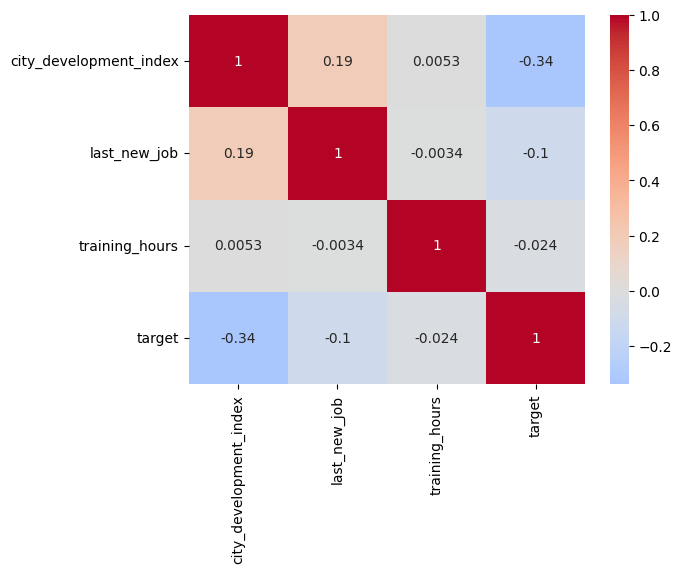

In [60]:
sns.heatmap(data.select_dtypes(include= np.number).corr(),annot=True, cmap='coolwarm', center=0)

In [61]:
px.scatter(data, x='city_development_index', y='training_hours',color= 'looking_for_job_change',color_discrete_sequence=['red','blue'],title='City Development Index vs Training Hours by Target')


In [62]:
px.scatter(data, x='last_new_job', y='training_hours',color= 'looking_for_job_change',color_discrete_sequence=['red','blue'],title='Years from last new job vs training hours by looking for job change')

In [63]:
data

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,looking_for_job_change
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,More_than_15,50-99,Pvt Ltd,1,36,1.0,Yes
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,10_to_15,50-99,Pvt Ltd,5,47,0.0,No
2,0.624,Male,No relevent experience,Full time course,Graduate,STEM,3_to_5,50-99,Pvt Ltd,0,83,0.0,No
3,0.789,Male,No relevent experience,no_enrollment,Graduate,Business Degree,less_than_3,50-99,Pvt Ltd,0,52,1.0,Yes
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,More_than_15,50-99,Funded Startup,4,8,0.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15946,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,10_to_15,100-500,Public Sector,3,23,0.0,No
15947,0.920,Female,Has relevent experience,no_enrollment,Graduate,Humanities,6_to_9,10/49,Funded Startup,1,25,0.0,No
15948,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,10_to_15,50-99,Pvt Ltd,1,42,1.0,Yes
15949,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,10_to_15,50-99,Pvt Ltd,4,52,1.0,Yes


In [64]:
#sns.heatmap(data.select_dtypes(include= np.number).corr(),annot=True, cmap='coolwarm', center=0)
#plt.show()

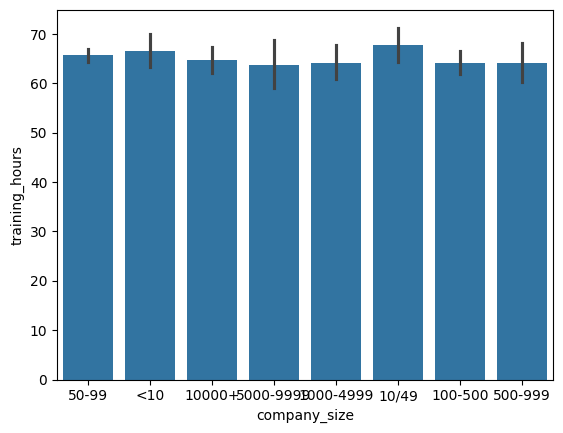

In [65]:
sns.barplot(data=data, x='company_size', y='training_hours')
plt.show()

In [66]:
data.select_dtypes(include= np.number).corr()

,city_development_index,last_new_job,training_hours,target
city_development_index,1.000000,0.191997,0.005289,-0.339280
last_new_job,0.191997,1.000000,-0.003404,-0.102310
training_hours,0.005289,-0.003404,1.000000,-0.023677
target,-0.339280,-0.102310,-0.023677,1.000000


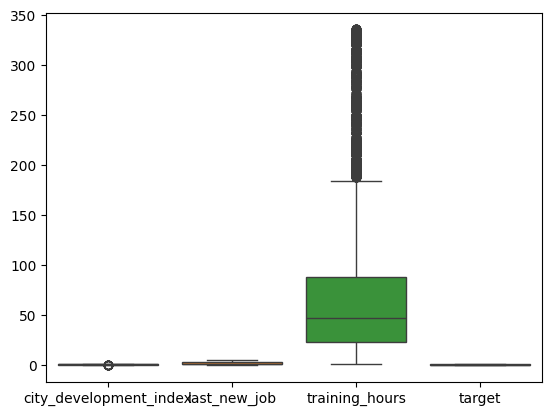

In [67]:
sns.boxplot(data)
plt.show()

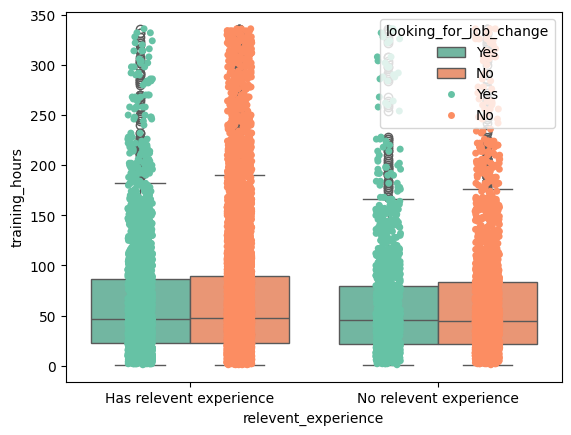

In [69]:
sns.boxplot(data= data, x='relevent_experience', y='training_hours', hue='looking_for_job_change', palette='Set2')
sns.stripplot(data= data, x='relevent_experience', y='training_hours', hue='looking_for_job_change', palette='Set2', dodge=True)
plt.show()

## dealing with outliers

In [70]:
for i in range(10):          # have to loop for detecting & deleting outliers becuase after deleting outliers the data is changed
    outliers= detect_outliers( data,0, [ 'training_hours', 'city_development_index'])
    data.drop(outliers, inplace=True) # Drop the outliers from the DataFrame
    data.reset_index(drop=True, inplace=True) # Reset the index of the DataFrame after dropping outliers

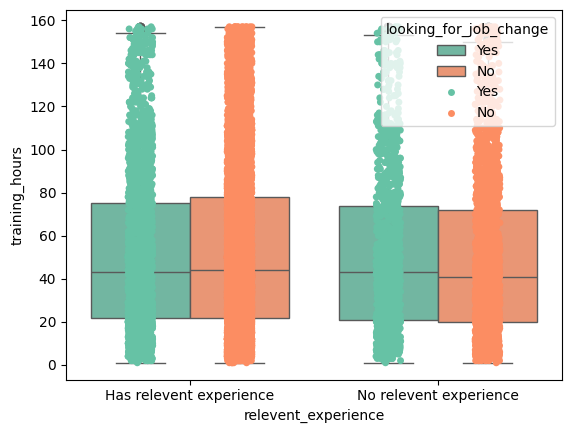

In [71]:
sns.boxplot(data, x='relevent_experience', y='training_hours', hue='looking_for_job_change', palette='Set2')
sns.stripplot(data, x='relevent_experience', y='training_hours', hue='looking_for_job_change', palette='Set2', dodge=True)
plt.show()

<Axes: >

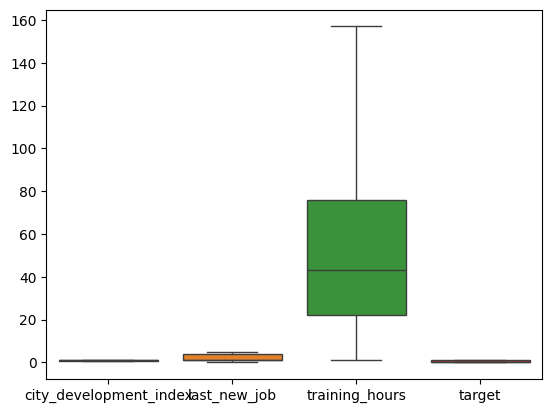

In [72]:
sns.boxplot(data)

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14654 entries, 0 to 14653
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  14654 non-null  float64
 1   gender                  14654 non-null  object 
 2   relevent_experience     14654 non-null  object 
 3   enrolled_university     14654 non-null  object 
 4   education_level         14654 non-null  object 
 5   major_discipline        14654 non-null  object 
 6   experience              14654 non-null  object 
 7   company_size            14654 non-null  object 
 8   company_type            14654 non-null  object 
 9   last_new_job            14654 non-null  int64  
 10  training_hours          14654 non-null  int64  
 11  target                  14654 non-null  float64
 12  looking_for_job_change  14654 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 1.5+ MB


In [74]:
data.to_csv("Data_cleaned.csv", index=False) # Save the cleaned data to a new CSV file

In [75]:
data

,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,looking_for_job_change
0,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,More_than_15,50-99,Pvt Ltd,1,36,1.0,Yes
1,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,10_to_15,50-99,Pvt Ltd,5,47,0.0,No
2,0.624,Male,No relevent experience,Full time course,Graduate,STEM,3_to_5,50-99,Pvt Ltd,0,83,0.0,No
3,0.789,Male,No relevent experience,no_enrollment,Graduate,Business Degree,less_than_3,50-99,Pvt Ltd,0,52,1.0,Yes
4,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,More_than_15,50-99,Funded Startup,4,8,0.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14649,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,10_to_15,100-500,Public Sector,3,23,0.0,No
14650,0.920,Female,Has relevent experience,no_enrollment,Graduate,Humanities,6_to_9,10/49,Funded Startup,1,25,0.0,No
14651,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,10_to_15,50-99,Pvt Ltd,1,42,1.0,Yes
14652,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,10_to_15,50-99,Pvt Ltd,4,52,1.0,Yes


## Dealing with categorical data

In [76]:
data = pd.get_dummies(data, columns= ['gender','relevent_experience','enrolled_university'],drop_first = True,dtype = 'int')
data.drop ('looking_for_job_change',axis =1 , inplace= True)
data

,city_development_index,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,enrolled_university_no_enrollment
0,0.920,Graduate,STEM,More_than_15,50-99,Pvt Ltd,1,36,1.0,1,0,0,0,1
1,0.776,Graduate,STEM,10_to_15,50-99,Pvt Ltd,5,47,0.0,1,0,1,0,1
2,0.624,Graduate,STEM,3_to_5,50-99,Pvt Ltd,0,83,0.0,1,0,1,0,0
3,0.789,Graduate,Business Degree,less_than_3,50-99,Pvt Ltd,0,52,1.0,1,0,1,0,1
4,0.767,Masters,STEM,More_than_15,50-99,Funded Startup,4,8,0.0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14649,0.920,Graduate,STEM,10_to_15,100-500,Public Sector,3,23,0.0,0,0,0,0,1
14650,0.920,Graduate,Humanities,6_to_9,10/49,Funded Startup,1,25,0.0,0,0,0,0,1
14651,0.878,Graduate,Humanities,10_to_15,50-99,Pvt Ltd,1,42,1.0,1,0,1,0,1
14652,0.920,Graduate,STEM,10_to_15,50-99,Pvt Ltd,4,52,1.0,1,0,0,0,1


## One hot encoder

In [77]:
onehot = OneHotEncoder(drop= 'first')
onehot.fit(data[['company_type','major_discipline']])
onehot

OneHotEncoder(drop='first')

In [78]:
onehot_df = onehot.transform(data[['company_type','major_discipline']])
onehot_df.toarray()

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(14654, 10))

In [79]:
df_encoded = pd.DataFrame(onehot_df.toarray(), columns= onehot.get_feature_names_out())
df_encoded


,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
14649,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
14650,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
14651,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
14652,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [80]:
data = pd.concat([data,df_encoded],axis =1)
data.drop(['company_type','major_discipline'],axis =1 , inplace= True)
data

,city_development_index,education_level,experience,company_size,last_new_job,training_hours,target,gender_Male,gender_Other,relevent_experience_No relevent experience,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM
0,0.920,Graduate,More_than_15,50-99,1,36,1.0,1,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.776,Graduate,10_to_15,50-99,5,47,0.0,1,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.624,Graduate,3_to_5,50-99,0,83,0.0,1,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.789,Graduate,less_than_3,50-99,0,52,1.0,1,0,1,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,0.767,Masters,More_than_15,50-99,4,8,0.0,1,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14649,0.920,Graduate,10_to_15,100-500,3,23,0.0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
14650,0.920,Graduate,6_to_9,10/49,1,25,0.0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
14651,0.878,Graduate,10_to_15,50-99,1,42,1.0,1,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
14652,0.920,Graduate,10_to_15,50-99,4,52,1.0,1,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## Label encoder

In [81]:
data['education_level'].unique()

array(['Graduate', 'Masters', 'Phd'], dtype=object)

In [82]:
education_level = {'Graduate': 0 , 'Masters': 1 , 'Phd': 2}
data['education_level'] = data['education_level'].map(education_level)

In [83]:
data['experience'].unique()

array(['More_than_15', '10_to_15', '3_to_5', 'less_than_3', '6_to_9'],
      dtype=object)

In [84]:
experience = {'less_than_3': 0 , '3_to_5': 1 , '6_to_9': 2 , '10_to_15': 3 , 'More_than_15': 4}
data['experience'] = data['experience'].map(experience)

In [85]:
data['company_size'].unique()

array(['50-99', '<10', '10000+', '5000-9999', '1000-4999', '10/49',
       '100-500', '500-999'], dtype=object)

In [86]:
company_size= {'<10': 0 , '10/49': 1 , '50-99': 2 , '100-500': 3 , '500-999': 4 ,'1000-4999' : 5,'5000-9999':6 ,'10000+': 7}
data['company_size']=data['company_size'].map(company_size)

In [87]:
data

,city_development_index,education_level,experience,company_size,last_new_job,training_hours,target,gender_Male,gender_Other,relevent_experience_No relevent experience,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM
0,0.920,0,4,2,1,36,1.0,1,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.776,0,3,2,5,47,0.0,1,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.624,0,1,2,0,83,0.0,1,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.789,0,0,2,0,52,1.0,1,0,1,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,0.767,1,4,2,4,8,0.0,1,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14649,0.920,0,3,3,3,23,0.0,0,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
14650,0.920,0,2,1,1,25,0.0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
14651,0.878,0,3,2,1,42,1.0,1,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
14652,0.920,0,3,2,4,52,1.0,1,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## Split data into x & y

In [88]:
x= data.drop(['target'],axis=1)
y= data['target']

## split data into train & test

In [89]:
x_train , x_test ,y_train , y_test = train_test_split(x,y , test_size = 0.2 ,stratify= y)

## scaling using standard scaler

In [90]:
standerd_scaler = StandardScaler()
x_train_scaled = standerd_scaler.fit_transform(x_train)
x_train_scaled = pd.DataFrame(x_train_scaled,columns = x_train.columns)

In [91]:
x_test_scaled = standerd_scaler.transform(x_test)
x_test_scaled = pd.DataFrame(x_test_scaled ,columns = x_test.columns)

## Handle impalance data

In [92]:
y_train.value_counts()

target
0.0    8697
1.0    3026
Name: count, dtype: int64

In [93]:
#! pip install imblearn


In [94]:
rus = RandomUnderSampler()
x_train_us , y_train_us = rus.fit_resample(x_train_scaled , y_train)

In [95]:
x_train_us = pd.DataFrame(x_train_us, columns = x_train.columns)
x_train_us

,city_development_index,education_level,experience,company_size,last_new_job,training_hours,gender_Male,gender_Other,relevent_experience_No relevent experience,enrolled_university_Part time course,...,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM
2270,-0.512683,-0.618516,0.452007,-0.492815,-1.283491,0.005746,0.295424,-0.095523,1.882498,-0.254288,...,-0.247566,-0.1762,-0.079702,-0.238112,0.46647,-0.143954,-0.204821,-0.119848,-0.1547,0.360001
2866,0.731594,-0.618516,1.209097,-0.492815,-0.085532,-0.419270,0.295424,-0.095523,-0.531209,-0.254288,...,-0.247566,-0.1762,-0.079702,-0.238112,0.46647,-0.143954,-0.204821,-0.119848,-0.1547,0.360001
8478,0.731594,-0.618516,-1.062173,2.048656,-0.684511,0.005746,0.295424,-0.095523,-0.531209,-0.254288,...,-0.247566,-0.1762,-0.079702,-0.238112,0.46647,-0.143954,-0.204821,-0.119848,-0.1547,0.360001
2855,0.731594,-0.618516,-1.819263,0.015479,-0.085532,-0.180198,0.295424,-0.095523,-0.531209,-0.254288,...,-0.247566,-0.1762,-0.079702,-0.238112,0.46647,-0.143954,-0.204821,-0.119848,-0.1547,0.360001
8538,0.512015,-0.618516,0.452007,0.015479,-0.684511,1.998013,0.295424,-0.095523,-0.531209,-0.254288,...,-0.247566,-0.1762,-0.079702,-0.238112,0.46647,-0.143954,-0.204821,-0.119848,-0.1547,0.360001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11689,0.967437,-0.618516,-1.819263,1.032068,-1.283491,-1.295868,0.295424,-0.095523,1.882498,-0.254288,...,-0.247566,-0.1762,-0.079702,-0.238112,0.46647,-0.143954,-0.204821,-0.119848,-0.1547,0.360001
11698,0.731594,-0.618516,0.452007,-0.492815,-0.684511,0.351073,0.295424,-0.095523,-0.531209,-0.254288,...,-0.247566,-0.1762,-0.079702,-0.238112,0.46647,-0.143954,-0.204821,-0.119848,-0.1547,0.360001
11699,0.544545,-0.618516,-0.305083,-0.492815,-0.684511,0.908907,0.295424,-0.095523,1.882498,-0.254288,...,-0.247566,-0.1762,-0.079702,-0.238112,0.46647,-0.143954,-0.204821,-0.119848,-0.1547,0.360001
11702,0.731594,-0.618516,-0.305083,2.048656,1.711406,0.749526,0.295424,-0.095523,-0.531209,-0.254288,...,-0.247566,-0.1762,-0.079702,-0.238112,0.46647,-0.143954,-0.204821,-0.119848,-0.1547,0.360001


In [96]:
y_train_us.value_counts()

target
0.0    3026
1.0    3026
Name: count, dtype: int64